# Oceananigans.jl: the tripolar grid

[Oceananigans.jl](https://github.com/CliMA/Oceananigans.jl) provides a
`TripolarGrid` (in its `OrthogonalSphericalShellGrids` submodule) for global
ocean simulations. Like NEMO/MOM it replaces the North-Pole singularity with two
poles over land and folds the northern edge of the domain onto itself (a
"zipper" boundary).

This example uses a small dataset generated by the companion Julia script
[`scripts/generate_oceananigans_tripolar.jl`](https://github.com/xgcm/xgcm-examples/blob/master/scripts/generate_oceananigans_tripolar.jl),
which builds a coarse `TripolarGrid`, fills a tracer and a horizontal velocity,
and writes the cell-centre/-corner longitudes and latitudes to NetCDF:

```julia
using Oceananigans
grid = TripolarGrid(size = (60, 40, 1), north_poles_latitude = 60)
```

Oceananigans' tracer zipper mirrors the seam axis **without** the half-cell roll
of NEMO's T-pivot — it corresponds to xgcm's `"u"` pivot.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from xgcm import Grid
from xgcm.padding import pad

ds = xr.open_dataset("oceananigans_tripolar.nc")
ds

<xarray.Dataset> Size: 211kB
Dimensions:  (y_c: 40, x_c: 60, y_f: 40, x_f: 60)
Dimensions without coordinates: y_c, x_c, y_f, x_f
Data variables:
    lon_cc   (y_c, x_c) float64 19kB ...
    lat_cc   (y_c, x_c) float64 19kB ...
    lon_ff   (y_f, x_f) float64 19kB ...
    lat_ff   (y_f, x_f) float64 19kB ...
    lon_fc   (y_c, x_f) float64 19kB ...
    lat_fc   (y_c, x_f) float64 19kB ...
    lon_cf   (y_f, x_c) float64 19kB ...
    lat_cf   (y_f, x_c) float64 19kB ...
    tracer   (y_c, x_c) float64 19kB ...
    u        (y_c, x_f) float64 19kB ...
    v        (y_f, x_c) float64 19kB ...
Attributes:
    title:                 Oceananigans.jl tripolar-grid example for xgcm
    source:                Oceananigans TripolarGrid; scripts/generate_oceana...
    north_poles_latitude:  60
    first_pole_longitude:  70

## The grid

`lon_cc`/`lat_cc` are the tracer-point longitudes/latitudes. The two northern
poles are clearly visible where the meridians converge over (here, arbitrary)
land positions.

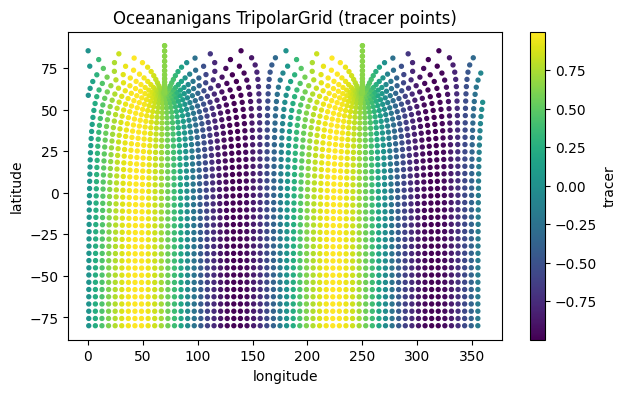

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
sc = ax.scatter(ds["lon_cc"], ds["lat_cc"], c=ds["tracer"], s=8, cmap="viridis")
ax.set(xlabel="longitude", ylabel="latitude",
       title="Oceananigans TripolarGrid (tracer points)")
fig.colorbar(sc, ax=ax, label="tracer")
plt.show()

## The north-fold boundary

We build a `Grid` on the tracer points with a periodic `X` seam and a north
fold on `Y`. Oceananigans' tracer zipper uses the `"u"` pivot.

In [3]:
tr = ds["tracer"].transpose("y_c", "x_c")
grid = Grid(
    tr.to_dataset(name="tracer"),
    coords={"X": {"center": "x_c"}, "Y": {"center": "y_c"}},
    boundary={"X": "periodic", "Y": {"fold": "u"}},
    autoparse_metadata=False,
)
grid

<xgcm.Grid>
X Axis (periodic, boundary='periodic'):
  * center   x_c
Y Axis (not periodic, boundary={'fold': 'u', 'south': 'fill'}):
  * center   y_c

In [4]:
# xgcm's folded halo should reproduce Oceananigans' own zipper exactly:
# the tracer halo mirrors the seam axis and sources the second-from-top row.
halo = pad(tr, grid, boundary_width={"Y": (0, 1)}).isel(y_c=-1).values
expected = tr.isel(y_c=-2).values[::-1]
print("max |xgcm fold halo - Oceananigans zipper| =",
      float(np.max(np.abs(halo - expected))))   # -> 0.0

max |xgcm fold halo - Oceananigans zipper| = 0.0


## Vectors flip sign across the fold

As for NEMO/MOM, horizontal velocity components reverse sign across the fold,
while scalars do not.

In [5]:
u = ds["u"].transpose("y_c", "x_f")   # zonal velocity  (X-edge, Y-centre)
v = ds["v"].transpose("y_f", "x_c")   # meridional vel.  (X-centre, Y-edge)
gridv = Grid(
    xr.Dataset(coords={"x_c": tr["x_c"], "x_f": u["x_f"],
                       "y_c": tr["y_c"], "y_f": v["y_f"]}),
    coords={"X": {"center": "x_c", "left": "x_f"},
            "Y": {"center": "y_c", "left": "y_f"}},
    boundary={"X": "periodic", "Y": {"fold": "u"}},
    autoparse_metadata=False,
)
v_scal = pad(v, gridv, boundary_width={"Y": (0, 1)}).isel(y_f=-1).values
v_vec = pad({"Y": v}, gridv, boundary_width={"Y": (0, 1)},
            other_component={"X": u}).isel(y_f=-1).values
print("max |vector halo + scalar halo| (the sign flip) =",
      float(np.max(np.abs(v_vec + v_scal))))   # -> 0.0

max |vector halo + scalar halo| (the sign flip) = 0.0


> See the [grid topology](../grid_topology.md) docs for the full fold
> specification, and the [MOM6](03_MOM6.ipynb) and [NEMO/IPSL](06_tripolar_fold.ipynb)
> examples for the other tripolar conventions.